# The angular grid inside Probabilistic FTR

`ProbabilisticFTR` decides whether to resume by asking for a probability, not a distance. It
computes `P(closest-approach offset > rpz)` under the uncertainty each aircraft declares, and
resumes once that clears `prob_threshold`. There is no closed form for that probability, so the
library integrates over the uncertain direction of the relative velocity numerically.

The integral is discretised on a grid of `ktheta` angles, and this library offers two rules for
placing them. `grid="uniform"` spreads `ktheta` points evenly around the full circle, which is what
the reference implementation did and what this library shipped until now. `grid="centred"` spends
the same points on the part of the circle where the integrand has mass, and is now the default at
`ktheta = 128`. The default `ktheta` follows the grid, because the two rules need different node
counts to be safe.

This notebook is the evidence for that switch. We look at accuracy first and cost second, because
the accuracy result is what decides whether the cost result matters.

Note that this notebook reaches into module internals (`_p_offset_gt`, `_log_p_theta`). That is
deliberate. The question here is about a quadrature rule that the public API hides.

In [1]:
%matplotlib inline
import math
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 130

from opencdarr.cns.noise_distributions import CI95_TO_SIGMA
from opencdarr.crr.probabilistic_ftr import (
    _HALF_WIDTH_SIGMAS, _iso_cov, _log_p_theta, _p_offset_gt, _phi, _theta_grid,
)

BLUE, RED, ORANGE, PURPLE, GREY = "#1f77b4", "#d62728", "#ff7f0e", "#9467bd", "0.55"

RPZ = 50.0          # protected zone radius, m
KTHETA_SHIPPED = 256

SITE_IMG = Path.home() / "Projects/opencdarr.github.io/docs/assets/img"

def save(fig, name):
    if SITE_IMG.is_dir():
        fig.savefig(SITE_IMG / f"{name}.png", dpi=130)
        print(f"wrote {name}.png")

## The encounter we integrate over

We take one ordinary encounter and hold it fixed for most of the notebook. The intruder sits 320 m
away, closing at a relative speed of 34.3 m/s. Both aircraft declare a position accuracy
(`pos_ci95`) of 6 m and a velocity accuracy (`vel_ci95`) of 1 m/s, which is what a decent GNSS fix
gives.

`_iso_cov` turns each declared 95% interval into a covariance, so the numbers below are the
variances the criterion actually integrates with.

In [2]:
POS_CI95, VEL_CI95 = 6.0, 1.0

mu_r = np.array([319.0, 20.0])                    # relative position, m
mu_v = np.array([-34.0, 4.5])                     # relative velocity, m/s
sigma_r = _iso_cov(POS_CI95) + _iso_cov(POS_CI95)  # both sides declare, errors add
sigma_v = _iso_cov(VEL_CI95) + _iso_cov(VEL_CI95)

sr2, sv2 = float(sigma_r[0, 0]), float(sigma_v[0, 0])
snr = float(np.hypot(*mu_v)) / math.sqrt(sv2)
theta_mu = math.atan2(mu_v[1], mu_v[0])

print(f"separation          {np.hypot(*mu_r):.1f} m")
print(f"closing speed       {np.hypot(*mu_v):.1f} m/s")
print(f"sigma_r             {math.sqrt(sr2):.2f} m")
print(f"sigma_v             {math.sqrt(sv2):.3f} m/s")
print(f"velocity SNR        {snr:.1f}      -> density peak width ~ 1/SNR = {1/snr:.4f} rad")
print(f"tail step width     {math.sqrt(sr2)/np.hypot(*mu_r):.4f} rad")
print(f"uniform grid step   {2*math.pi/KTHETA_SHIPPED:.4f} rad   (ktheta = {KTHETA_SHIPPED})")

separation          319.6 m
closing speed       34.3 m/s
sigma_r             3.47 m
sigma_v             0.578 m/s
velocity SNR        59.4      -> density peak width ~ 1/SNR = 0.0168 rad
tail step width     0.0108 rad
uniform grid step   0.0245 rad   (ktheta = 256)


## Two sharp features, one uniform grid

The integrand is a product of two functions of the angle `theta`. The first is the angular density
of the relative velocity direction, which `_log_p_theta` evaluates. The second is the conditional
tail `P(offset > rpz | theta)`, which is the folded-normal probability the derivation writes out.

Both are narrow, and they are narrow for different reasons.

The density concentrates around the mean direction with a width of roughly `1/SNR` radians, where
`SNR` is the closing speed divided by `sigma_v`. A well-known velocity means a well-known
direction. The tail switches from 0 to 1 over a width of roughly `sigma_r / |mu_r|` radians,
because a small angular change swings the projection of a 320 m separation vector by much more than
the 3.5 m position uncertainty.

wrote probftr_grid_integrand.png
4 of 256 shipped grid nodes land inside the +-3-sigma peak


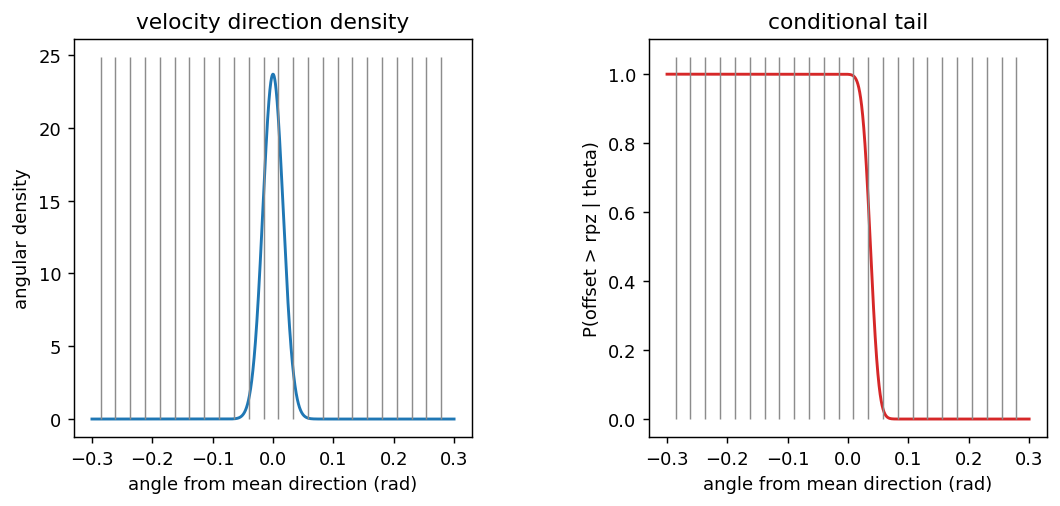

In [3]:
def tail_on_grid(theta, mu_r, sr2, x=RPZ):
    """P(offset > x | theta), the folded-normal tail of the projection onto u_perp."""
    ct, st = np.cos(theta), np.sin(theta)
    m = -st * mu_r[0] + ct * mu_r[1]
    s = math.sqrt(sr2)
    return 1.0 - np.clip(_phi((x - m) / s) - _phi((-x - m) / s), 0.0, 1.0)

window = 0.30
fine = theta_mu + np.linspace(-window, window, 4000)
dens = np.exp(_log_p_theta(fine, mu_v, sigma_v))
nodes = np.linspace(0.0, 2 * math.pi, KTHETA_SHIPPED, endpoint=False)
inside = nodes[np.abs(np.angle(np.exp(1j * (nodes - theta_mu)))) < window]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))
ax1.plot(fine - theta_mu, dens, color=BLUE, lw=1.6)
ax1.vlines(inside - theta_mu, 0, dens.max() * 1.05, color=GREY, lw=0.8)
ax1.set_xlabel("angle from mean direction (rad)"); ax1.set_ylabel("angular density")
ax1.set_title("velocity direction density")
ax2.plot(fine - theta_mu, tail_on_grid(fine, mu_r, sr2), color=RED, lw=1.6)
ax2.vlines(inside - theta_mu, 0, 1.05, color=GREY, lw=0.8)
ax2.set_xlabel("angle from mean direction (rad)"); ax2.set_ylabel("P(offset > rpz | theta)")
ax2.set_title("conditional tail")
for ax in (ax1, ax2):
    ax.set_box_aspect(1)
fig.tight_layout()
save(fig, "probftr_grid_integrand")

peak = np.abs(np.angle(np.exp(1j * (nodes - theta_mu)))) < 3 / snr
print(f"{peak.sum()} of {KTHETA_SHIPPED} shipped grid nodes land inside the +-3-sigma peak")

Both panels span 0.6 rad, a tenth of the circle, with the grey lines marking the shipped grid nodes
that fall inside it. The density on the left is a spike 0.017 rad wide. The tail on the right is
close to a step, and it is narrower still at 0.011 rad.

Four of the 256 nodes land inside the peak. The whole integral is therefore decided by four
samples, and their position relative to the peak depends on where the aircraft happens to be
heading. That is the failure mode we go on to measure.

## A grid centred on the mean direction

The alternative keeps the number of nodes and moves them. We compute the mean direction from
`mu_v`, then spread `ktheta` points evenly across a window of plus or minus eight angular standard
deviations around it. Beyond eight sigma the density carries no mass worth integrating.

At low `SNR` the density is broad rather than peaked, and it has mass everywhere on the circle. The
window then reaches the full circle on its own, and the rule falls back to the uniform grid without
a special case.

Spacing stays uniform inside the window, so the weights are normalised exactly as before. Only the
node positions change.

In [4]:
# Both rules come straight from the library, so this notebook measures the shipped code rather
# than a reimplementation of it. _theta_grid takes the covariance matrix; every covariance here is
# isotropic, so eye(2) * variance rebuilds it exactly.
def uniform_grid(ktheta, mu_v=None, sv2=None):
    """grid="uniform": the library's full-circle rule."""
    mu = np.zeros(2) if mu_v is None else mu_v
    return _theta_grid(ktheta, mu, np.eye(2) * (1.0 if sv2 is None else sv2), "uniform")

def centred_grid(ktheta, mu_v, sv2):
    """grid="centred": the library's peak-centred rule, the current default."""
    return _theta_grid(ktheta, mu_v, np.eye(2) * sv2, "centred")

def p_offset_gt_on(theta, x, mu_r, sigma_r, mu_v, sigma_v):
    """The _p_offset_gt integrand, evaluated on an angle grid we supply."""
    log_w = _log_p_theta(theta, mu_v, sigma_v)
    log_w = log_w - np.max(log_w)
    w = np.exp(log_w)
    w = w / w.sum()
    return float(np.clip(np.sum(tail_on_grid(theta, mu_r, float(sigma_r[0, 0]), x) * w), 0.0, 1.0))

### Where each rule puts its samples

The plot below gives both rules the same budget of 64 nodes and marks the value each one reads off
the density. The left panel is the whole circle, the middle panel is the peak at the scale of the
window, and the right panel is the conditional tail over the same span as the middle.

wrote probftr_grid_sampling.png
 uniform, 64 nodes:  1 inside the +-3-sigma peak, largest single weight 0.996
 centred, 64 nodes: 24 inside the +-3-sigma peak, largest single weight 0.101


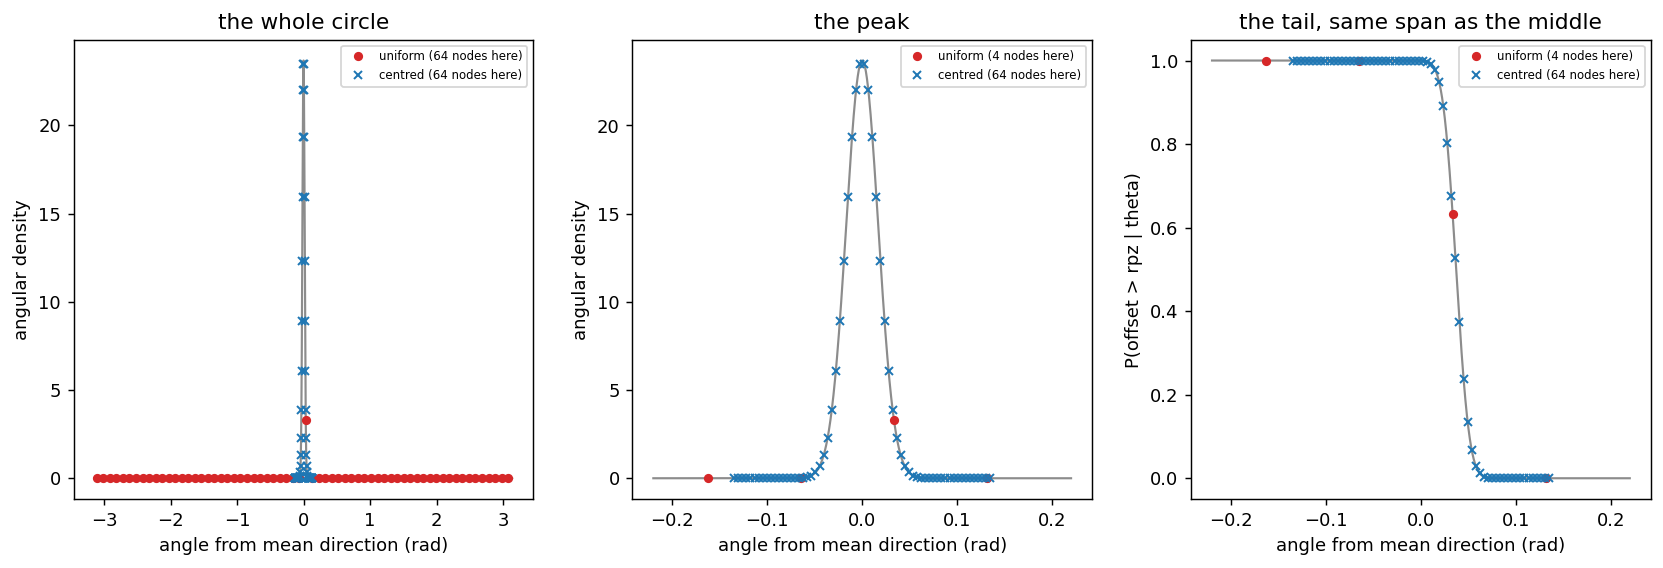

In [5]:
K_DEMO = 64
gu = uniform_grid(K_DEMO, mu_v, sv2)
gc = centred_grid(K_DEMO, mu_v, sv2)
wrap = lambda t: np.angle(np.exp(1j * (t - theta_mu)))   # offset from the mean direction

full = theta_mu + np.linspace(-math.pi, math.pi, 6000)
zoom = theta_mu + np.linspace(-0.22, 0.22, 4000)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, xs, title in ((axes[0], full, "the whole circle"), (axes[1], zoom, "the peak")):
    ax.plot(wrap(xs), np.exp(_log_p_theta(xs, mu_v, sigma_v)), color=GREY, lw=1.2, zorder=1)
    for g, colour, marker, label in ((gu, RED, "o", "uniform"), (gc, BLUE, "x", "centred")):
        keep = np.abs(wrap(g)) <= np.abs(wrap(xs)).max()
        ax.plot(wrap(g[keep]), np.exp(_log_p_theta(g[keep], mu_v, sigma_v)), marker,
                ms=4, mew=1.1, color=colour, ls="none", label=f"{label} ({keep.sum()} nodes here)")
    ax.set_xlabel("angle from mean direction (rad)"); ax.set_ylabel("angular density")
    ax.set_title(title); ax.legend(fontsize=6.5)

axes[2].plot(wrap(zoom), tail_on_grid(zoom, mu_r, sr2), color=GREY, lw=1.2, zorder=1)
for g, colour, marker, label in ((gu, RED, "o", "uniform"), (gc, BLUE, "x", "centred")):
    keep = np.abs(wrap(g)) <= 0.22
    axes[2].plot(wrap(g[keep]), tail_on_grid(g[keep], mu_r, sr2), marker, ms=4, mew=1.1,
                 color=colour, ls="none", label=f"{label} ({keep.sum()} nodes here)")
axes[2].set_xlabel("angle from mean direction (rad)")
axes[2].set_ylabel("P(offset > rpz | theta)")
axes[2].set_title("the tail, same span as the middle"); axes[2].legend(fontsize=6.5)
for ax in axes:
    ax.set_box_aspect(1)
fig.tight_layout()
save(fig, "probftr_grid_sampling")

for label, g in (("uniform", gu), ("centred", gc)):
    w = np.exp(_log_p_theta(g, mu_v, sigma_v))
    print(f"{label:>8}, {K_DEMO} nodes: {int((np.abs(wrap(g)) < 3/snr).sum()):>2} inside the "
          f"+-3-sigma peak, largest single weight {w.max()/w.sum():.3f}")

The uniform rule spends 60 of its 64 nodes outside the span of the middle panel, on the flat part
of the circle where the density is zero to double precision and the samples contribute nothing.
Exactly one node falls within three angular sigma of the peak, and it carries 99.6% of the
normalised weight. The integral is a one-point estimate, and that point moves as the intruder's
heading moves.

The centred rule puts all 64 nodes inside the window, 24 of them within three angular sigma. The
largest single weight drops to 0.101, so no one sample decides the answer. The right panel shows
the same nodes landing across the tail transition rather than either side of it.

This is also why adding nodes to the uniform grid helps so erratically. Doubling `ktheta` does not
refine the peak, it re-rolls which sample happens to sit near it.

The comparison is honest only against a probability we trust. We build a reference grid resolved to
thirty points across whichever of the two features is narrower, then check it against a plain Monte
Carlo estimate that samples `r` and `v` directly and needs no quadrature at all.

In [6]:
def reference_p(x, mu_r, sigma_r, mu_v, sigma_v, per_feature=30, cap=65536):
    """Grid resolved to `per_feature` points across the narrower of the two sharp features."""
    sr2, sv2 = float(sigma_r[0, 0]), float(sigma_v[0, 0])
    snr = float(np.hypot(*mu_v)) / math.sqrt(sv2)
    step = math.sqrt(sr2) / max(float(np.hypot(*mu_r)), 1e-12)
    finest = min(1.0 / max(snr, 1e-12), max(step, 1e-9))
    half_width = min(math.pi, 60.0 / snr) if snr > 8.0 else math.pi
    ktheta = min(cap, max(4096, int(math.ceil(2 * half_width / (finest / per_feature)))))
    if half_width >= math.pi:
        theta = np.linspace(0.0, 2.0 * math.pi, ktheta, endpoint=False)
    else:
        theta = math.atan2(mu_v[1], mu_v[0]) + np.linspace(-half_width, half_width, ktheta)
    return p_offset_gt_on(theta, x, mu_r, sigma_r, mu_v, sigma_v)

def monte_carlo_p(x, mu_r, sigma_r, mu_v, sigma_v, n, seed):
    """P(|d| > x) by sampling r and v, with no angular integration anywhere."""
    rng = np.random.default_rng(seed)
    r = mu_r + rng.normal(0.0, math.sqrt(float(sigma_r[0, 0])), (n, 2))
    v = mu_v + rng.normal(0.0, math.sqrt(float(sigma_v[0, 0])), (n, 2))
    d = r - v * ((r * v).sum(1) / (v * v).sum(1))[:, None]
    p = float((np.hypot(d[:, 0], d[:, 1]) > x).mean())
    return p, 1.96 * math.sqrt(max(p * (1.0 - p), 1e-12) / n)

ref = reference_p(RPZ, mu_r, sigma_r, mu_v, sigma_v)
mc, ci = monte_carlo_p(RPZ, mu_r, sigma_r, mu_v, sigma_v, 4_000_000, seed=20260803)
print(f"reference quadrature   {ref:.6f}")
print(f"Monte Carlo, 4e6       {mc:.6f} +- {ci:.6f} (95%)")
print(f"agreement              {'yes' if abs(ref - mc) <= ci else 'no':>3}, gap {abs(ref-mc):.2e}")

reference quadrature   0.967489
Monte Carlo, 4e6       0.967487 +- 0.000174 (95%)
agreement              yes, gap 2.27e-06


## One encounter, both grids

With a trusted answer in hand we sweep `ktheta` for each rule. The old default of 256 uniform is
marked in the table, alongside the new default of 64 centred.

In [7]:
print(f"reference P(offset > rpz) = {ref:.6f}\n")
print(f"{'ktheta':>7}  {'uniform':>10} {'error':>10}   {'centred':>10} {'error':>10}")
for k in (16, 32, 64, 128, 256, 1024, 4096):
    pu = p_offset_gt_on(uniform_grid(k, mu_v, sv2), RPZ, mu_r, sigma_r, mu_v, sigma_v)
    pc = p_offset_gt_on(centred_grid(k, mu_v, sv2), RPZ, mu_r, sigma_r, mu_v, sigma_v)
    mark = ("  <- was the default" if k == KTHETA_SHIPPED else
            "  <- centred is the default here" if k == 64 else "")
    print(f"{k:>7}  {pu:>10.6f} {abs(pu-ref):>10.2e}   {pc:>10.6f} {abs(pc-ref):>10.2e}{mark}")

reference P(offset > rpz) = 0.967489

 ktheta     uniform      error      centred      error
     16    0.000000   9.67e-01     0.967388   1.00e-04
     32    1.000000   3.25e-02     0.967489   2.50e-13
     64    0.633890   3.34e-01     0.967489   3.77e-15  <- centred is the default here
    128    0.934799   3.27e-02     0.967489   1.33e-15
    256    0.965969   1.52e-03     0.967489   1.78e-15  <- was the default
   1024    0.967489   7.77e-16     0.967489   2.00e-15
   4096    0.967489   8.88e-16     0.967489   1.11e-15


The centred grid is correct to 1e-4 at 16 nodes and to machine precision from 32 upward. The
uniform grid does not converge monotonically at all. It reads 0.000 at 16 nodes, 1.000 at 32, 0.634
at 64 and 0.935 at 128, before landing within 1.5e-3 at the shipped 256 and becoming exact around
1024. Those first four values are not approximations of 0.967, they are different answers.

The non-monotonic sequence is the signature of the sampling problem, not of slow convergence.
Adding nodes moves them relative to the peak rather than resolving it.

A single encounter proves nothing on its own. The next section repeats this across a population.

## Across a population of encounters

We sample 400 encounters with separations from 100 m to 800 m, closing speeds from 0.5 m/s to
45 m/s, `pos_ci95` from 1 m to 30 m and `vel_ci95` from 0.05 m/s to 6 m/s. The last two brackets
span a good GNSS fix at one end and a degraded one at the other.

For each encounter we record the error in the probability, and whether the grid would have changed
the resume decision at the default `prob_threshold` of 0.999. The decision is what the criterion
actually returns, so it is the number that matters operationally.

In [8]:
PROB_THRESHOLD = 0.999
rng = np.random.default_rng(20260803)
N_CASES = 400

cases = []
for _ in range(N_CASES):
    bearing = rng.uniform(0.0, 2.0 * math.pi)
    rho = rng.uniform(100.0, 800.0)
    speed = rng.uniform(0.5, 45.0)
    heading = rng.uniform(0.0, 2.0 * math.pi)
    cases.append((
        np.array([rho * math.cos(bearing), rho * math.sin(bearing)]),
        _iso_cov(rng.uniform(1.0, 30.0)) * 2.0,
        np.array([speed * math.cos(heading), speed * math.sin(heading)]),
        _iso_cov(10.0 ** rng.uniform(-1.3, 0.78)) * 2.0,
    ))

refs = [reference_p(RPZ, *c) for c in cases]
snrs = [float(np.hypot(*c[2])) / math.sqrt(float(c[3][0, 0])) for c in cases]

variants = {"uniform, ktheta 64": (uniform_grid, 64),
            "uniform, ktheta 256": (uniform_grid, KTHETA_SHIPPED),
            "centred, ktheta 64": (centred_grid, 64)}
errors, flips = {}, {}
for label, (grid, k) in variants.items():
    ps = [p_offset_gt_on(grid(k, c[2], float(c[3][0, 0])), RPZ, *c) for c in cases]
    errors[label] = [abs(p - r) for p, r in zip(ps, refs)]
    flips[label] = sum((p > PROB_THRESHOLD) != (r > PROB_THRESHOLD) for p, r in zip(ps, refs))

print(f"{N_CASES} encounters, threshold {PROB_THRESHOLD}\n")
print(f"{'grid':<22} {'max error':>10} {'median error':>13} {'decisions changed':>19}")
for label in variants:
    e = errors[label]
    print(f"{label:<22} {max(e):>10.2e} {np.median(e):>13.2e} "
          f"{flips[label]:>10d}  ({flips[label]/N_CASES:>5.1%})")

400 encounters, threshold 0.999

grid                    max error  median error   decisions changed
uniform, ktheta 64       6.65e-01      2.22e-16          4  ( 1.0%)
uniform, ktheta 256      1.15e-01      1.11e-16          1  ( 0.2%)
centred, ktheta 64       2.44e-02      1.56e-16          0  ( 0.0%)


wrote probftr_grid_accuracy.png


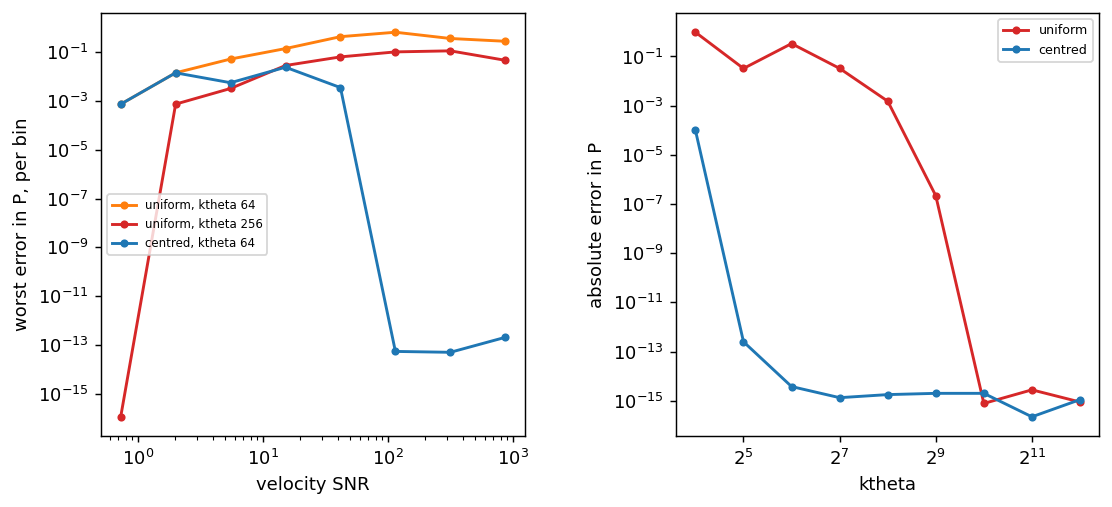

In [9]:
edges = np.logspace(math.log10(min(snrs)), math.log10(max(snrs)), 9)
mids = np.sqrt(edges[:-1] * edges[1:])
snr_arr = np.array(snrs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))
for label, colour in (("uniform, ktheta 64", ORANGE), ("uniform, ktheta 256", RED),
                      ("centred, ktheta 64", BLUE)):
    err = np.array(errors[label])
    worst = [max(err[(snr_arr >= lo) & (snr_arr < hi)].max(), 1e-17)
             if ((snr_arr >= lo) & (snr_arr < hi)).any() else np.nan
             for lo, hi in zip(edges[:-1], edges[1:])]
    ax1.plot(mids, worst, marker="o", ms=3.5, lw=1.6, color=colour, label=label)
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.set_xlabel("velocity SNR"); ax1.set_ylabel("worst error in P, per bin")
ax1.legend(fontsize=6.5, loc="center left")

ks = [16, 32, 64, 128, 256, 512, 1024, 2048, 4096]
for grid, colour, label in ((uniform_grid, RED, "uniform"), (centred_grid, BLUE, "centred")):
    ax2.plot(ks, [max(abs(p_offset_gt_on(grid(k, mu_v, sv2), RPZ, mu_r, sigma_r, mu_v, sigma_v)
                          - ref), 1e-17) for k in ks],
             marker="o", ms=3.5, lw=1.6, color=colour, label=label)
ax2.set_xscale("log", base=2); ax2.set_yscale("log")
ax2.set_xlabel("ktheta"); ax2.set_ylabel("absolute error in P")
ax2.legend(fontsize=7)
for ax in (ax1, ax2):
    ax.set_box_aspect(1)
fig.tight_layout()
save(fig, "probftr_grid_accuracy")

Worst error in each of eight SNR bins on the left, across all 400 encounters, and the convergence
of the single encounter on the right. Points at the floor are exact to double precision. We plot
the worst case per bin rather than every point, because the typical encounter is exact under every
rule and the question here is how bad the rules get.

Most encounters are fine under every rule, which is why the median error is at the double-precision
floor in all three rows of the table. The failures are a minority and they are severe. The uniform
grid at 256 is wrong by up to 0.115 in a probability compared against a threshold of 0.999, and it
changed 1 resume decision in 400. At `ktheta = 64` the uniform grid is wrong by up to 0.665 and
changed 4 decisions in 400, which is why the two rules do not share a default `ktheta`.

The centred grid at `ktheta = 64` holds the maximum error to 0.024 and changed no decision, on a
quarter of the nodes.

That last row is why the shipped default is `ktheta = 128` rather than 64. A per-call bound of 0.024
is not the same as a safe default. One end-to-end encounter in the test suite, at a velocity SNR of
about 13, needs 96 nodes to come out right, and a single flipped resume decision there changes the
whole flown trajectory. The final section explains what 64 is missing.

The left panel shows that the two rules fail at opposite ends. The uniform grid gets worse as
velocity SNR rises, climbing from 3.3e-3 in the 3 to 9 bin to 1.2e-1 above 190 at `ktheta = 256`.
That is backwards, because a better velocity fix narrows the density and a fixed grid then resolves
it worse.

The centred grid runs the other way. It reaches double precision above an SNR of about 25 and
carries all of its residual error below that, peaking at 2.4e-2 in the 9 to 25 bin. Below an SNR of
about 2.5 the window opens to the full circle, so the two rules coincide by construction. The final
section explains what is left over down there.

## Cost

The centred grid costs one `atan2` and one `hypot` more than the uniform grid at equal `ktheta`, so
at fixed node count the two are the same price. Any saving has to come from needing fewer nodes.

There is a second axis. `_phi` calls `erf` three times per evaluation, and this library uses SciPy's
when it is installed (`pip install opencdarr[fast]`) and a numpy fallback otherwise. We measure both
axes below, because they interact.

Timings on a laptop drift with thermal state, so we interleave the two measurements and report the
best of several rounds. Treat the ratio as the result and the microseconds as indicative.

In [10]:
def bench_all(cases, n=300, rounds=9):
    # Best-of-N per case, with every case re-measured inside each round. A laptop's clock speed
    # drifts with thermal state and with whatever else is running, so measuring one case to
    # completion before starting the next compares them at different moments and can invert the
    # answer. Rotating through all cases every round samples each one across the whole span.
    best = {label: math.inf for label, _ in cases}
    for label, fn in cases:
        fn()
    for _ in range(rounds):
        for label, fn in cases:
            t = time.perf_counter_ns()
            for _ in range(n):
                fn()
            best[label] = min(best[label], (time.perf_counter_ns() - t) / n / 1000.0)
    return best

import opencdarr.crr.probabilistic_ftr as _pftr

_elementwise = np.frompyfunc(math.erf, 1, 1)
numpy_erf = lambda x: np.asarray(_elementwise(x), dtype=np.float64)
old_erf = np.vectorize(math.erf)          # what this module used before
installed_erf = _pftr._erf                 # scipy's if it is present

CONFIGS = [("uniform 256 (was default)", 256, "uniform"),
           ("centred 128 (default)", 128, "centred"),
           ("centred 64", 64, "centred")]
BACKENDS = [("scipy", installed_erf), ("numpy fallback", numpy_erf), ("old np.vectorize", old_erf)]

def call(ktheta, grid, erf):
    def run():
        _pftr._erf = erf                   # swapped per call, so no backend gets a warmer machine
        return _p_offset_gt(RPZ, mu_r, sigma_r, mu_v, sigma_v, ktheta, grid)
    return run

cases = [(f"{bname}|{label}", call(k, g, fn))
         for bname, fn in BACKENDS for label, k, g in CONFIGS]
best = bench_all(cases)
_pftr._erf = installed_erf

print(f"{'us per call':>28} " + "".join(f"{b:>18}" for b, _ in BACKENDS))
for label, _, _ in CONFIGS:
    print(f"{label:>28} " + "".join(f"{best[f'{b}|{label}']:>18.1f}" for b, _ in BACKENDS))

ref = best[f"old np.vectorize|uniform 256 (was default)"]
print(f"\nspeedup against the old default (uniform 256, np.vectorize erf):")
for bname, _ in BACKENDS:
    print(f"  {bname:<17} " + "  ".join(
        f"{label}: {ref / best[f'{bname}|{label}']:.2f}x" for label, _, _ in CONFIGS))

                 us per call              scipy    numpy fallback  old np.vectorize
   uniform 256 (was default)              942.2            1238.7            1775.2
       centred 128 (default)             1039.5            1187.2            1196.7
                  centred 64              768.3             813.1            1352.2

speedup against the old default (uniform 256, np.vectorize erf):
  scipy             uniform 256 (was default): 1.88x  centred 128 (default): 1.71x  centred 64: 2.31x
  numpy fallback    uniform 256 (was default): 1.43x  centred 128 (default): 1.50x  centred 64: 2.18x
  old np.vectorize  uniform 256 (was default): 1.00x  centred 128 (default): 1.48x  centred 64: 1.31x


Read the columns, not the rows. **Almost all of the speed is in the `erf` backend, and almost none
of it is in the grid.**

Down a column, halving the node count from 256 to 128 buys little, because what is left is fixed
overhead in `_log_p_theta` rather than per-node work. Across a row, swapping the backend is worth
substantially more. On the `np.vectorize` column the node count still matters, since that
implementation reruns a Python loop per call and its cost tracks `ktheta` directly. That is why an
earlier reading of this notebook overstated the grid's contribution. Once `erf` stops being the
bottleneck, `ktheta` mostly stops mattering.

So the honest summary is that **the centred grid is an accuracy change that happens to be roughly
cost-neutral**, and the `erf` backend is the speed change. They are independent, and the grid would
be worth making even if it cost more.

Absolute timings drift hard with thermal state and with whatever else is running, and this cell
measures from inside a Jupyter kernel, so treat the shape of the table as the result and the
microseconds as indicative. The same comparison run standalone on an idle machine came out around
three times faster in absolute terms while keeping the same shape, and
`vault/observations/probftr-angular-grid.md` records that run. If your own numbers disagree by a
factor, check what else is using the CPU before believing them.

`should_resume` calls this function up to twice per active pair per timestep, so whatever the ratio
is, it lands on every timestep of every conflict.

## What the centred grid does not fix

The window is built from the density alone. It ignores the tail, which is the second sharp feature,
and at low SNR the tail is the narrower of the two.

Below we hold the geometry fixed and widen `vel_ci95`, which drags SNR down. The density spreads
out, the window opens to the full circle, and the grid is then back to spacing that cannot resolve
a tail step of `sigma_r / |mu_r|`.

In [11]:
far_r = np.array([634.7, 10.0])
far_sr = _iso_cov(2.0) * 2.0
print(f"{'vel_ci95':>9} {'SNR':>7} {'tail step':>11} {'window':>9}   "
      f"{'centred 64':>11} {'error':>10}")
for vel_ci95 in (0.2, 0.5, 1.0, 3.0, 6.0, 12.0):
    sv = _iso_cov(vel_ci95) * 2.0
    s = float(np.hypot(*mu_v)) / math.sqrt(float(sv[0, 0]))
    hw = math.pi if s <= 0 else min(math.pi, _HALF_WIDTH_SIGMAS / s)
    r_ = reference_p(RPZ, far_r, far_sr, mu_v, sv)
    p_ = p_offset_gt_on(centred_grid(64, mu_v, float(sv[0, 0])), RPZ, far_r, far_sr, mu_v, sv)
    step = math.sqrt(float(far_sr[0, 0])) / float(np.hypot(*far_r))
    print(f"{vel_ci95:>9.1f} {s:>7.1f} {step:>11.5f} {hw:>9.3f}   {p_:>11.6f} {abs(p_-r_):>10.2e}")

 vel_ci95     SNR   tail step    window    centred 64      error
      0.2   296.8     0.00182     0.027      1.000000   2.22e-16
      0.5   118.7     0.00182     0.067      1.000000   1.11e-16
      1.0    59.4     0.00182     0.135      0.999973   2.50e-07
      3.0    19.8     0.00182     0.404      0.903159   8.87e-03


      6.0     9.9     0.00182     0.809      0.788151   2.41e-02
     12.0     4.9     0.00182     1.617      0.756159   1.00e-02


Accuracy holds to double precision while `vel_ci95` is 0.5 m/s or better, and decays to 2.4e-2 by
6 m/s as the window opens past 0.8 rad. The tail step stays at 0.0018 rad throughout, so what
changes is the spacing, not the feature.

Resolving the tail as well would mean adding nodes around the two angles where the projection
crosses `rpz`. That is a second refinement this notebook does not make.

The practical reading is that the centred grid removes the failure mode that bites in normal
operation, where a good velocity fix makes SNR high, and leaves a smaller one in the corner where
the velocity fix is poor. That remainder is not academic. It is what sets the default `ktheta` at
128 instead of 64, because an encounter at SNR ~13 in the test suite comes out wrong at 64.

The principled fix is to size the grid from both features rather than from the density alone, which
means giving the grid rule the position uncertainty it currently never sees. That is not built.

The research note behind this notebook is `vault/observations/probftr-angular-grid.md`, which also
records the two tests in `tests/test_probabilistic_ftr.py` that had been calibrated against the
uniform grid's error and were corrected when the default changed.

To reproduce the reference implementation's numbers, pass `ProbabilisticFTR(grid="uniform")`, which
restores the full-circle rule and its `ktheta` of 256.